In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import root
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

In [2]:

def pump_ss(x, Delta_p, s):

    ap = x[0] + 1j*x[1]

    f = -(1+1j*Delta_p)*ap -1j*abs(ap)**2*ap + s

    return [np.real(f), np.imag(f)]

def solve_pump(Delta_p, s):

    sol = root(pump_ss,[1,0],args=(Delta_p,s))

    ap = sol.x[0] + 1j*sol.x[1]

    return ap

In [3]:
def stability_matrix(ap, Delta_s, Delta_i):

    M = np.array([
        [-(1+1j*Delta_s) -1j*2*abs(ap)**2, -1j*ap**2],
        [1j*np.conj(ap)**2, -(1-1j*Delta_i) +1j*2*abs(ap)**2]
    ])

    return M

In [4]:
def parametric_gain(ap, Delta_s, Delta_i):

    M = stability_matrix(ap,Delta_s,Delta_i)

    eigvals = np.linalg.eigvals(M)

    return np.max(np.real(eigvals))

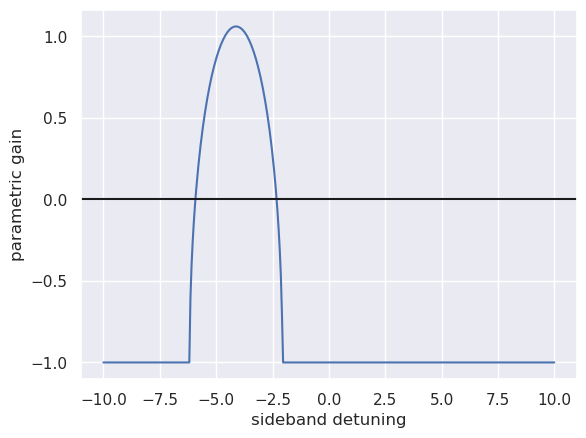

In [8]:
Delta_p = 2
s = 6

ap = solve_pump(Delta_p,s)

deltas = np.linspace(-10,10,400)

gain = []

for d in deltas:

    gain.append(parametric_gain(ap,d,d))

plt.plot(deltas,gain)
plt.axhline(0,color='k')

plt.xlabel("sideband detuning")
plt.ylabel("parametric gain")

plt.show()

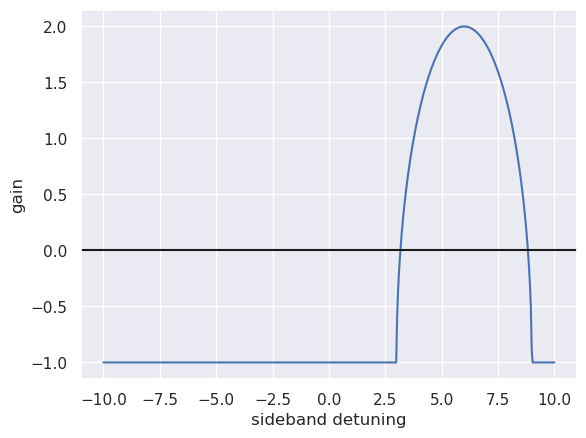

In [6]:
import numpy as np
import matplotlib.pyplot as plt

P = 3

Delta_mu = np.linspace(-10,10,500)

gain = -1 + np.sqrt(np.maximum(0, P**2 - (Delta_mu - 2*P)**2))

plt.plot(Delta_mu,gain)
plt.axhline(0,color='k')

plt.xlabel("sideband detuning")
plt.ylabel("gain")

plt.show()